# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




3.0 + 2.0 x + 1.0 x**2
[-1.-1.41421356j -1.+1.41421356j]
[-1.-1.41421356j -1.+1.41421356j]


In [4]:
import numpy as np
from numpy.polynomial import Polynomial

w = Polynomial([2, 3, 1])
print("Pierwiastki W(x) = x^2 + 3x + 2:")
print(w.roots())

true_roots = np.arange(1, 16)
p15 = Polynomial.fromroots(true_roots)
print("Utworzono wielomian o pierwiastkach od 1 do 15.")

calc_roots = p15.roots()
print("\nObliczone pierwiastki wielomianu stopnia 15:")
print(calc_roots.real)

error = np.max(np.abs(np.sort(calc_roots.real) - true_roots))
print(f"Maksymalny błąd bezwzględny obliczonych pierwiastków: {error:.2e}")

Pierwiastki W(x) = x^2 + 3x + 2:
[-2. -1.]
Utworzono wielomian o pierwiastkach od 1 do 15.

Obliczone pierwiastki wielomianu stopnia 15:
[ 1.          2.          3.          4.00000002  4.99999984  6.00000078
  6.99999766  8.00000426  8.99999644  9.99999742 11.0000111  11.99998569
 13.00000991 13.9999963  15.00000059]
Maksymalny błąd bezwzględny obliczonych pierwiastków: 1.43e-05


***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

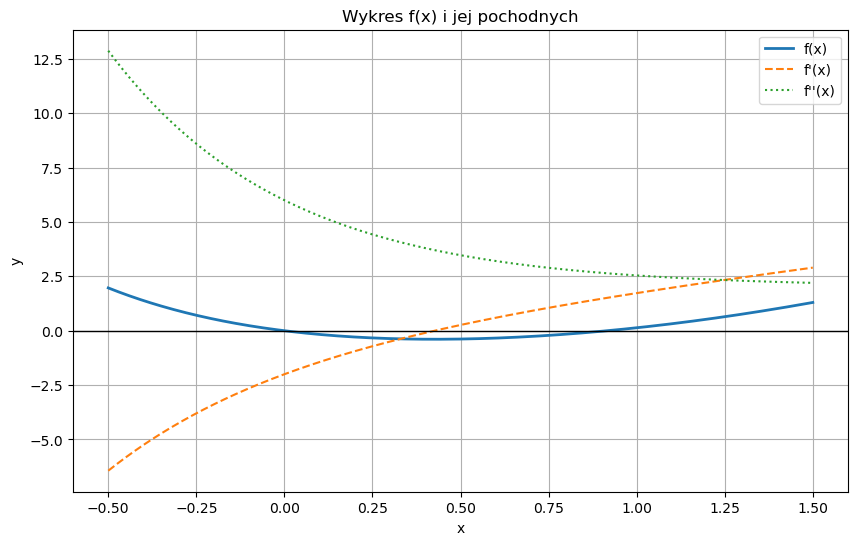

In [ ]:
def f(x):
    return np.exp(-2*x) + x**2 - 1

def df(x):
    return -2*np.exp(-2*x) + 2*x

def ddf(x):
    return 4*np.exp(-2*x) + 2

x = np.linspace(-0.5, 1.5, 400)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label='f(x)', linewidth=2)
plt.plot(x, df(x), label="f'(x)", linestyle='--')
plt.plot(x, ddf(x), label="f''(x)", linestyle=':')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Wykres f(x) i jej pochodnych')
plt.legend()
plt.grid()
plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [6]:
def bisekcja(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) > 0:
        return None, 0, []
    
    history = []
    for i in range(max_iter):
        c = (a + b) / 2
        history.append(c)
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return c, i + 1, history
        if f(c) * f(a) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2, max_iter, history

def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
    x = x0
    history = [x]
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            return x, i + 1, history
        dfx = df(x)
        if dfx == 0:
            return None, i + 1, history # Zabezpieczenie przed dzieleniem przez 0
        x_new = x - fx / dfx
        history.append(x_new)
        if abs(x_new - x) < tol:
            return x_new, i + 1, history
        x = x_new
    return x, max_iter, history

def sieczne(f, x0, x1, tol=1e-6, max_iter=100):
    history = [x0, x1]
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1) < tol:
            return x1, i + 1, history
        if fx1 - fx0 == 0:
            return None, i + 1, history
        
        x_new = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        history.append(x_new)
        if abs(x_new - x1) < tol:
            return x_new, i + 1, history
        
        x0, x1 = x1, x_new
    return x_new, max_iter, history

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [7]:
print("Rozwiązywanie dla miejsca zerowego ~0.9:")
r_bis, it_bis, hist_bis = bisekcja(f, 0.5, 1.5)
print(f"Bisekcja: root = {r_bis:.6f}, iteracji = {it_bis}")

r_newton, it_newton, hist_newton = newton_raphson(f, df, 1.5)
print(f"Newton:   root = {r_newton:.6f}, iteracji = {it_newton}")

r_sec, it_sec, hist_sec = sieczne(f, 0.5, 1.5)
print(f"Sieczne:  root = {r_sec:.6f}, iteracji = {it_sec}")

print("\nRozwiązywanie dla miejsca zerowego x = 0:")
r_bis0, it_bis0, hist_bis0 = bisekcja(f, -0.5, 0.4)
print(f"Bisekcja: root = {r_bis0:.6f}, iteracji = {it_bis0}")

r_newton0, it_newton0, hist_newton0 = newton_raphson(f, df, -0.5)
print(f"Newton:   root = {r_newton0:.6f}, iteracji = {it_newton0}")


Rozwiązywanie dla miejsca zerowego ~0.9:
Bisekcja: root = 0.916563, iteracji = 19
Newton:   root = 0.916563, iteracji = 5
Sieczne:  root = 0.916563, iteracji = 7

Rozwiązywanie dla miejsca zerowego x = 0:
Bisekcja: root = -0.000000, iteracji = 19
Newton:   root = -0.000000, iteracji = 6


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

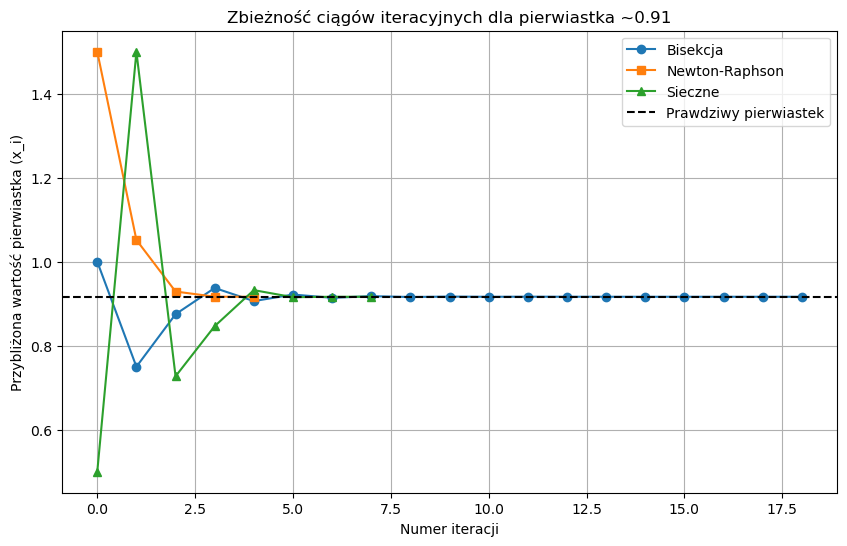

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(hist_bis, marker='o', label='Bisekcja')
plt.plot(hist_newton, marker='s', label='Newton-Raphson')
plt.plot(hist_sec, marker='^', label='Sieczne')
plt.axhline(r_bis, color='black', linestyle='--', label='Prawdziwy pierwiastek')
plt.xlabel('Numer iteracji')
plt.ylabel('Przybliżona wartość pierwiastka (x_i)')
plt.title('Zbieżność ciągów iteracyjnych dla pierwiastka ~0.91')
plt.legend()
plt.grid()
plt.show()